Below is my implementation of getting the band diamgrams utilizng the MPB library of Meep

In [42]:
# Importing Libraries: 

import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 
from meep import mpb

%matplotlib inline 

In [43]:
def banddiagram_wmpb(width, length, diameter):
    # width - width of our beam in nanometers
    # length - length of our beam in nanometers
    # diameter - diameter of the holes in patterned into the beam in nanometers

    # It is to note that Meep utlizes normalized units, so I set the length scale to the length of our unit cell
    c = 3e8

    # Parameters for the computational cell: 
    pml_padding = length  
    padding_to_pml = 4*length
    sx = 1       # We will scale the dimensions of everything else by the length (for example we scaled the paddings above by the length)
    sy = 2*(pml_padding + padding_to_pml + width)/length  
    res = 64     # I had set the resolution to a power of two, I dont know if that will aid in the computational speed but Meep mentioned somewhere in the documentation to do this

    cell = mp.Vector3(sx,sy)
    lattice = mp.Lattice(mp.Vector3(1,1))

    # For the silicon we want to use and our approximate target wavelength is below: 
    eps_silicon = 12
    thickness = 220
    wavelength = 1540 

    # Defining our waveguide given the parameters, meep assumes periodic structure: 
    beam = mp.Block(size = (1, width/length, thickness/length), material = mp.Medium(epsilon = eps_silicon) )
    holes = mp.Cylinder(radius = (diameter/2)/length, height = thickness/length, material = mp.Medium(epsilon = 1))

    geometry = [beam,holes]

    # Other things for simulation: It is to note that say we want to run for a certian number of periods, then we would divide our time by the frequency below
    fcenter = length/wavelength           # In meep units, the frequency is specified by 1/lambda according to https://meep.readthedocs.io/en/latest/Introduction/#units-in-meep
    df = .5*fcenter

    sym = mp.Mirror(direction=mp.Y, phase=-1)
    # Broad source to excite modes
    source = mp.Source(mp.GaussianSource(fcenter, fwidth = df), mp.Hz, mp.Vector3(0, 0))
    pml_layers = [mp.PML(pml_padding/length, direction =mp.Y)]

    simulation = mp.Simulation(
        cell_size = cell, 
        boundary_layers = pml_layers, 
        geometry = geometry, 
        sources = [source], 
        resolution = res, 
        symmetries=[sym]
    )

    f = plt.figure(dpi=200)
    simulation.plot2D(ax = f.gca())
    f.gca().xaxis.set_visible(False)
    f.suptitle('Geometry of Simulation')
    plt.show()

    # It was more or less the same to the prior implementation of this code, now we will utlize MPB to get the band diagrams: 
    num_bands = 8
    k_points = [mp.Vector3(0), mp.Vector3(.5)]       # Two dimensional simulation but only getting the x component of the wave vectors
    k_points = mp.interpolate(62, k_points)         # Interpolation to get more k vectors for our simulation, set to another power of two
    
    # mpb implementation of the mode solver: 
    ms = mpb.ModeSolver(
        num_bands = num_bands, 
        k_points= k_points, 
        geometry= geometry, 
        geometry_lattice= lattice, 
        resolution= res 
    )

    # We will split the modes up into TE and TM modes: 
    ms.run_te()
    te = ms.all_freqs       # The column index represents the frequencies for the index+1 band
    
    ms.run_tm()
    tm = ms.all_freqs

    plot_k = np.array(k_points)
    plot_te_freqs = np.array(te)*(c/(length*1e3))
    plot_tm_freqs = (np.array(tm))*(c/(length*1e3))

    #legends = [f'Mode {i+1}' for i in range(num_bands)] Legend is useless when we know modes go up increasing frequency 

    fig = plt.figure(num = 1,dpi = 200, figsize = (10,10))
    ax1 = plt.subplot(2,1,1)
    ax1.plot(plot_k[:,0].T, plot_te_freqs)
    ax1.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
    #ax1.set_ylabel('$\omega$  $[\\frac{2\pi c}{a}]$')
    ax1.set_ylabel('f [THz]')
    ax1.set_title('Band Diagram for TE Modes')
    #ax1.legend(legends)
    
    ax2 = plt.subplot(2,1,2)
    ax2.plot(plot_k[:,0].T, plot_tm_freqs)
    ax2.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
    #ax2.set_ylabel('$\omega$  $[\\frac{2\pi c}{a}]$')
    ax2.set_ylabel('f [THz]')
    ax2.set_title('Band Diagram for TM Modes')
    #ax2.legend(legends)

    plt.tight_layout()
    plt.show()

    
    


<>:84: SyntaxWarning: invalid escape sequence '\p'
<>:92: SyntaxWarning: invalid escape sequence '\p'
<>:84: SyntaxWarning: invalid escape sequence '\p'
<>:92: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1415617/2524314573.py:84: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
/tmp/ipykernel_1415617/2524314573.py:92: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')


     block, center = (0,0,0)
          size (1,0.833333,0.366667)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 0.366667, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)


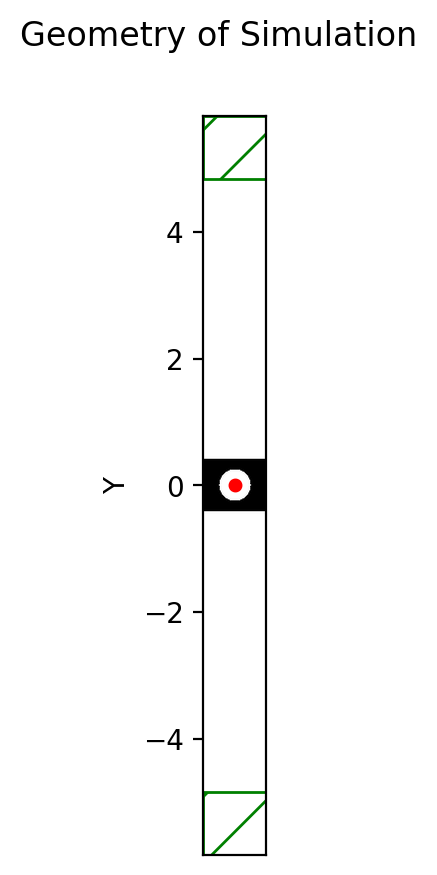

Initializing eigensolver data
Computing 8 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 8 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,0.833333,0.366667)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.25, height 0.366667, axis (0, 0, 1)
Geometric object tree has depth 2 and 5 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
64 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.007936507936507936, 0.0, 0.0>
  Vector3<0.015873015873015872, 0.0, 0.0>
  Vector3<0.023809523809523808, 0.0, 0.0>
  Vector3<0.031746031746031744, 0.0, 0.0>
  Vector3<0.03968253

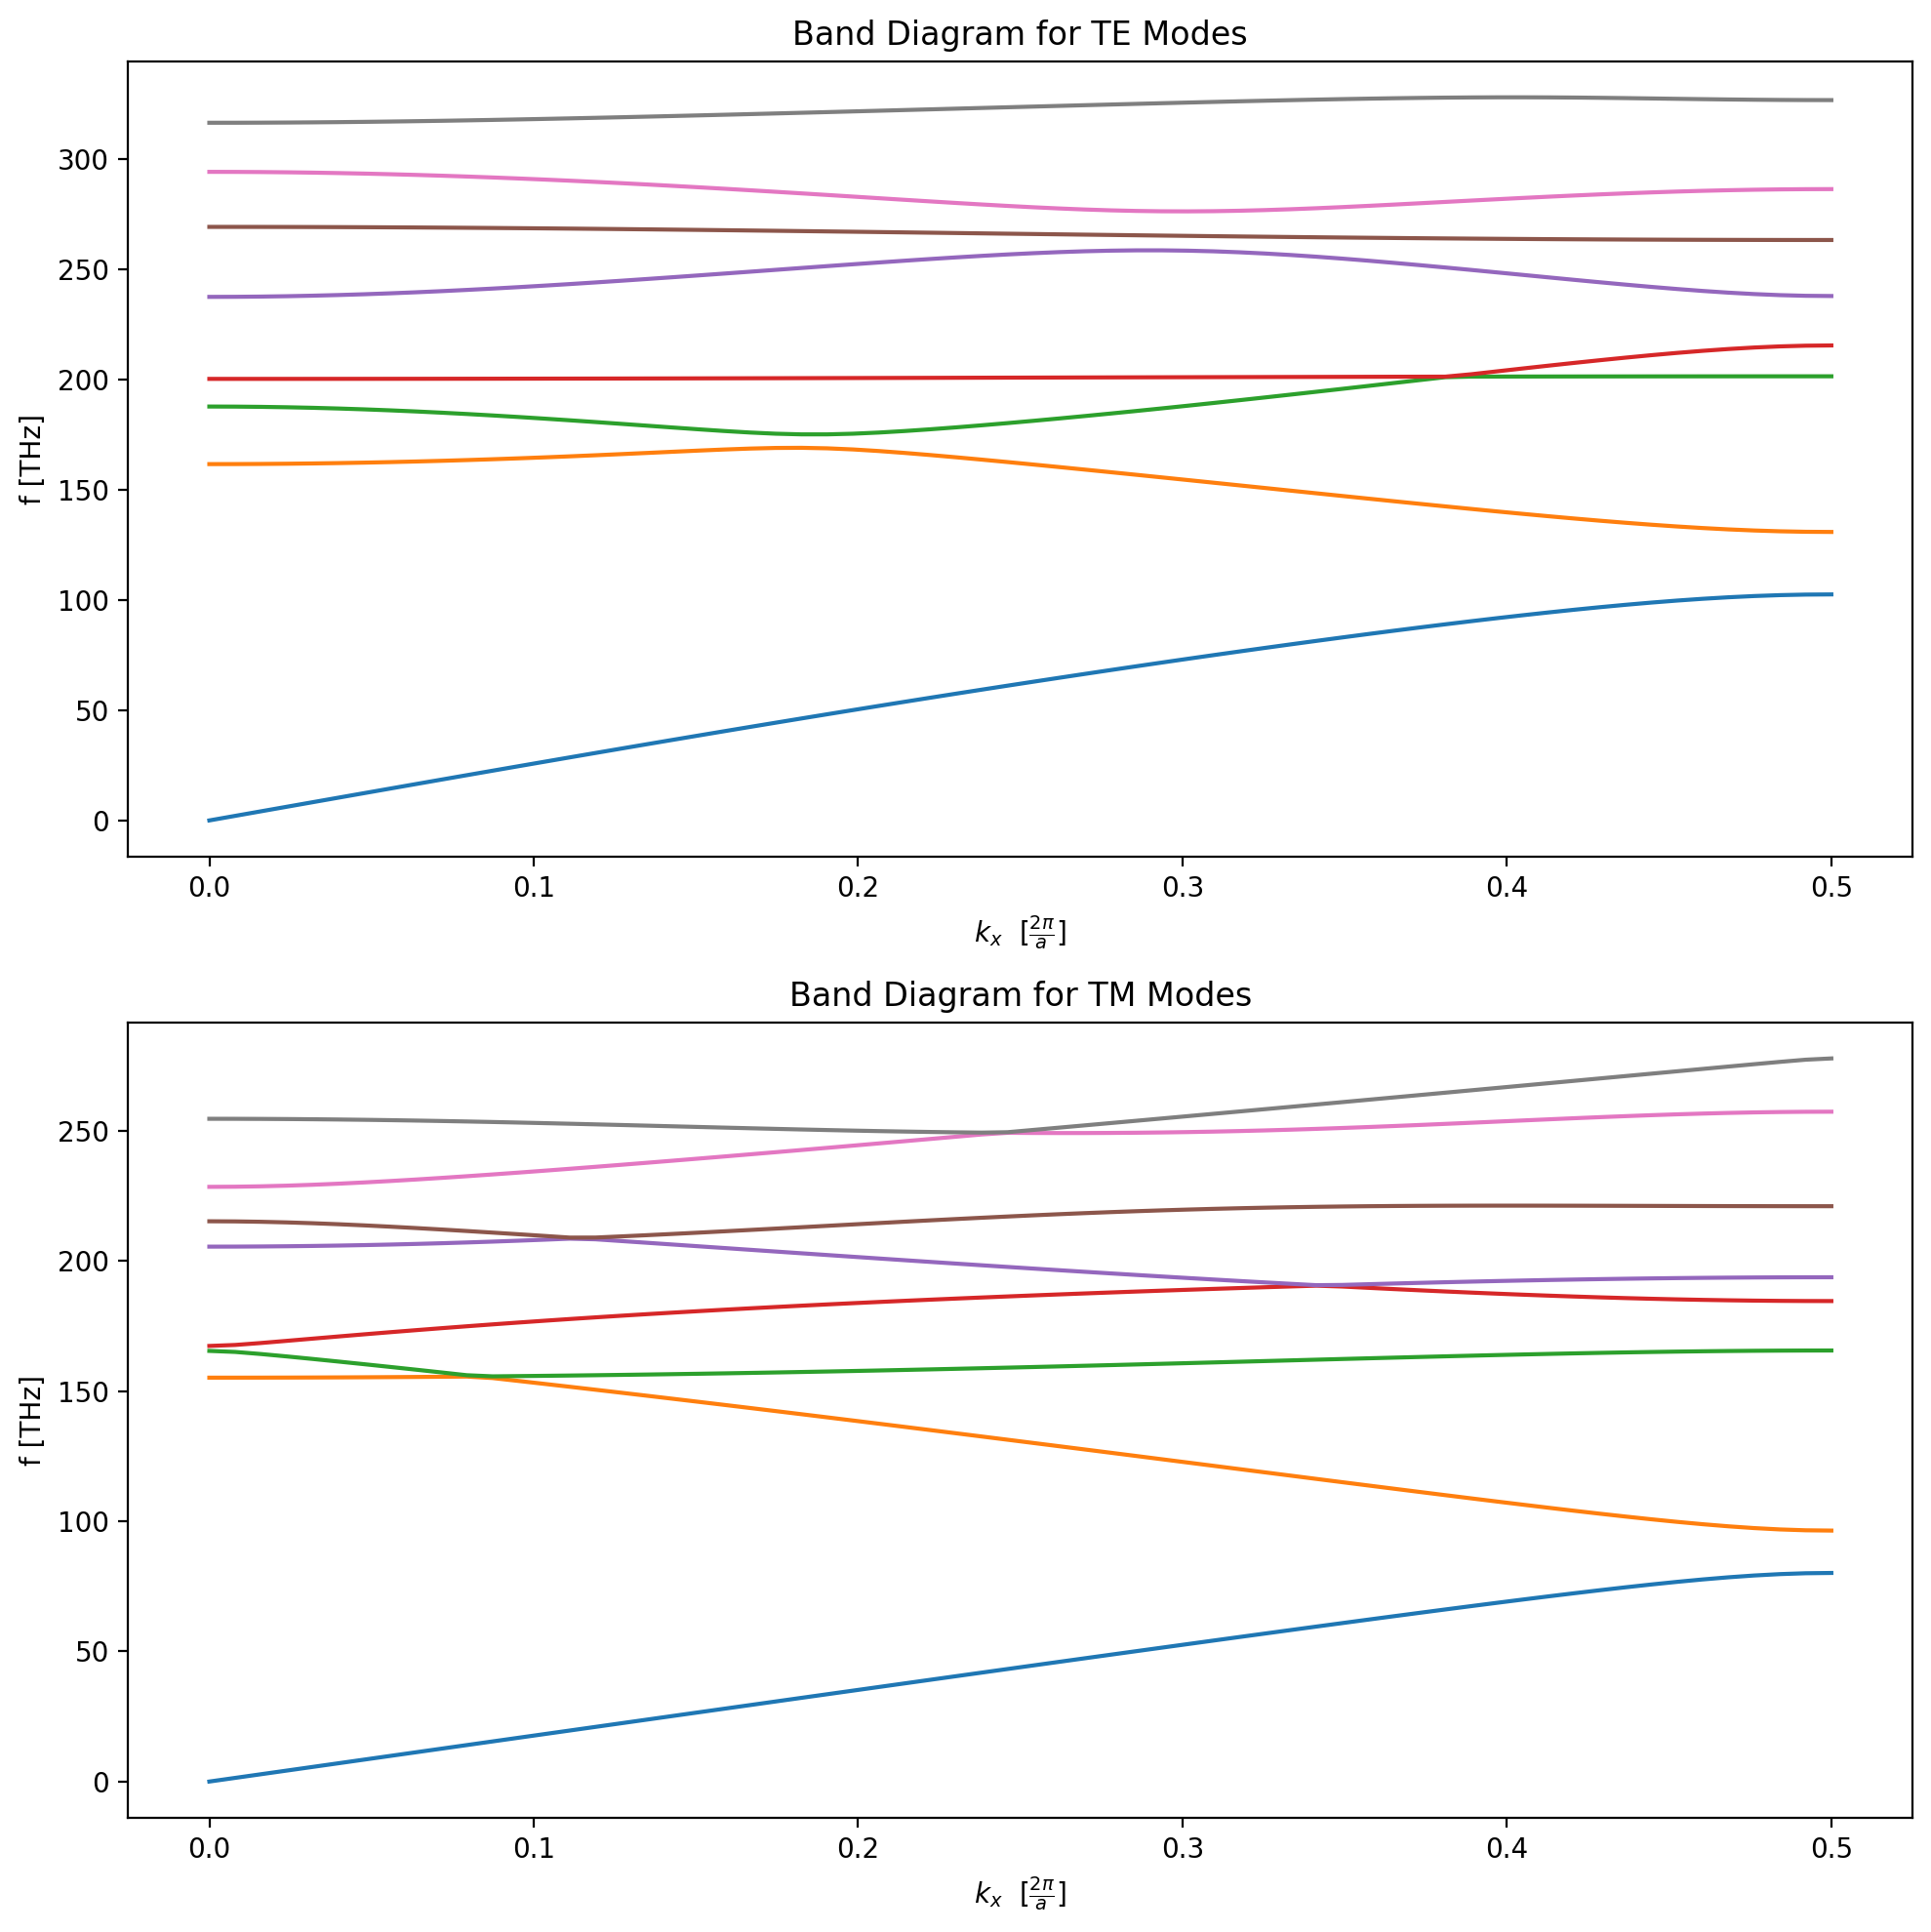

In [44]:
banddiagram_wmpb(500,600,300)

Notes for myself: 
little trouble figuring out that ms was an object that stored that runs specific frequencies. To access the frequencies, you use the .allfreq attribute. Depending on your use case of the run functions, this could return all the frequencies, i.e. both TM and TE freqs. Had to do a little refresher on the plotting with python (was too used to matlab plotting and indexing)

A little confused on how to resolve the light cone here